In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set the style for plots
sns.set_palette("deep")

In [3]:
# Load control and experimental data
control_data = np.loadtxt('/home/awelch/GIPL/control_model/out/mean.txt', skiprows=0, unpack=False)
experimental_data = np.loadtxt('/home/awelch/GIPL/warming_experiment_1C/out/mean.txt', skiprows=0,  unpack=False)

# Convert to pd data frame
control_df = pd.DataFrame(control_data, columns=['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m', 'idk', 'idk', 'idk'])
experimental_df = pd.DataFrame(experimental_data, columns = ['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m', 'idk', 'idk', 'idk'])

# Select needed columns
# Select 2nd column (index 1) and columns 5-11 (indices 4-10)
control_df = control_df.iloc[:, [1] + list(range(4, 11))]
experimental_df = experimental_df.iloc[:, [1] + list(range(4, 11))]

In [4]:
# Create a new 'year' column assigning years 1 to 10
control_df['year'] = range(1, 11)
experimental_df['year'] = range(1, 11)

# Set 'year' as the index
control_df.set_index('year', inplace=True)
experimental_df.set_index('year', inplace=True)

# Assuming the data has columns: 'time', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'
depths = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']

print(control_df.head())
print(experimental_df.head())

        time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
year                                                         
1      183.0 -3.925 -5.450 -6.143 -6.428 -6.689 -6.857 -7.012
2      548.0 -3.142 -4.474 -5.085 -5.322 -5.503 -5.620 -5.724
3      913.0 -2.898 -4.169 -4.758 -4.978 -5.130 -5.228 -5.309
4     1278.0 -2.720 -3.952 -4.524 -4.734 -4.873 -4.966 -5.040
5     1643.0 -2.632 -3.839 -4.400 -4.605 -4.729 -4.817 -4.880
        time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
year                                                         
1      183.0 -3.790 -5.336 -6.040 -6.330 -6.599 -6.773 -6.931
2      548.0 -2.965 -4.312 -4.940 -5.182 -5.368 -5.490 -5.595
3      913.0 -2.570 -3.864 -4.473 -4.702 -4.868 -4.982 -5.071
4     1278.0 -2.134 -3.413 -4.026 -4.257 -4.418 -4.539 -4.623
5     1643.0 -1.922 -3.179 -3.782 -4.005 -4.150 -4.267 -4.341


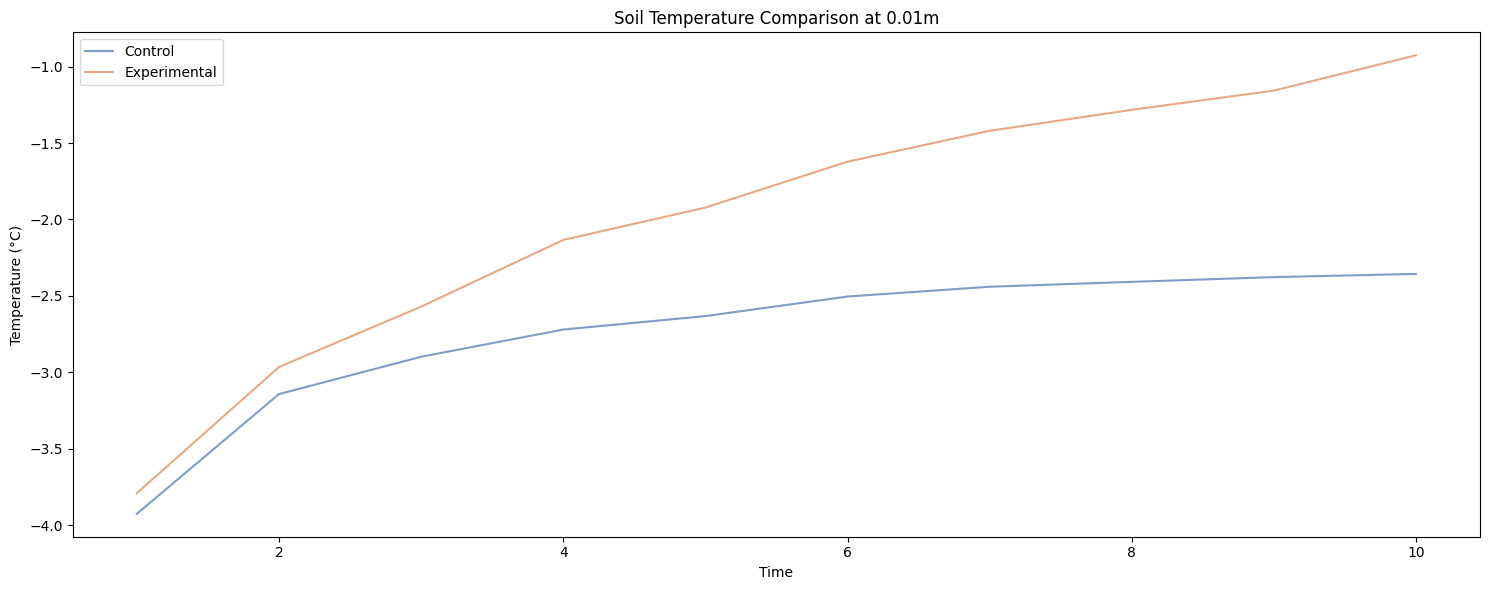

Statistics for 0.01m:
Control mean temperature: -2.74°C
Experimental mean temperature: -1.98°C
Temperature difference: 0.76°C
T-statistic: -2.3463
P-value: 0.0306




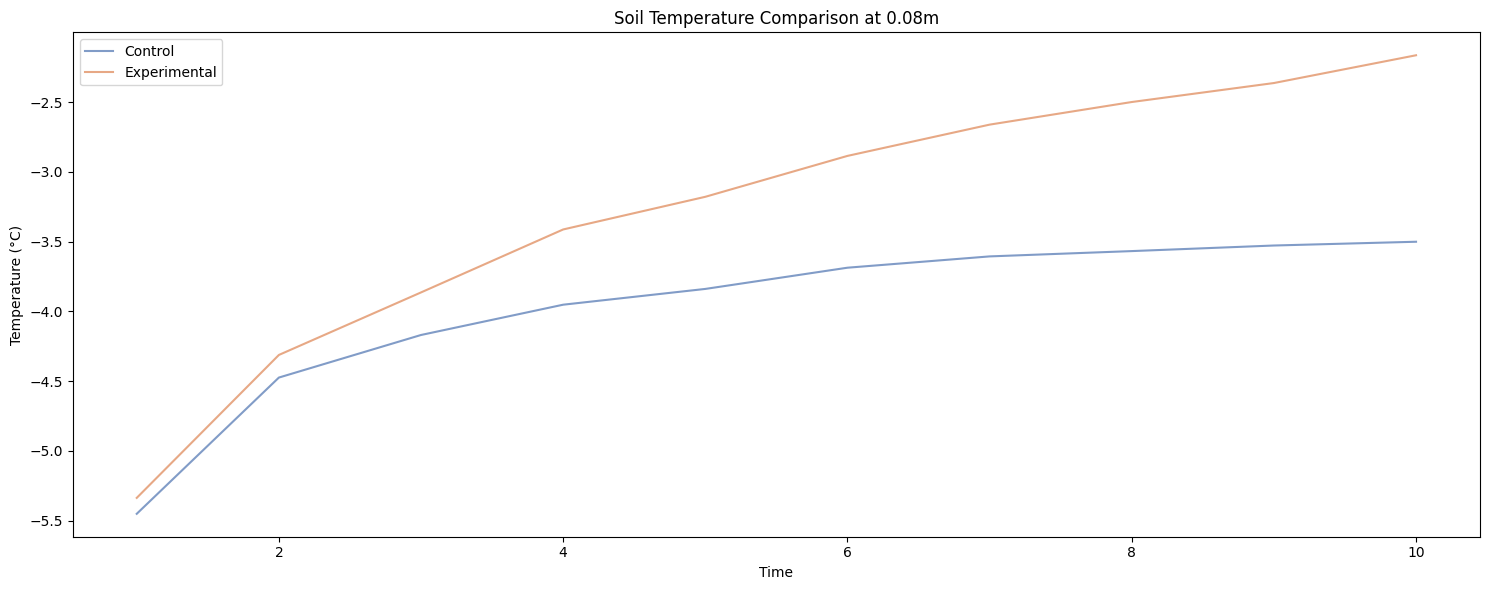

Statistics for 0.08m:
Control mean temperature: -3.98°C
Experimental mean temperature: -3.27°C
Temperature difference: 0.71°C
T-statistic: -1.9282
P-value: 0.0698




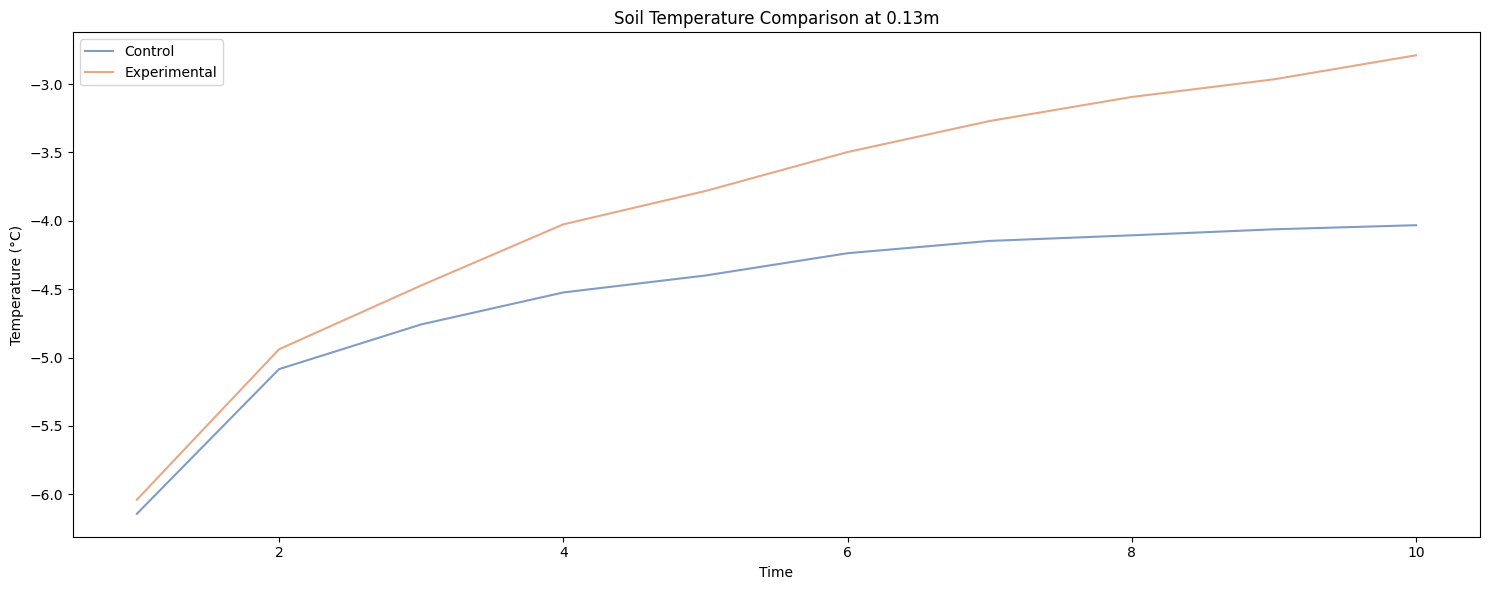

Statistics for 0.13m:
Control mean temperature: -4.55°C
Experimental mean temperature: -3.89°C
Temperature difference: 0.66°C
T-statistic: -1.7288
P-value: 0.1010




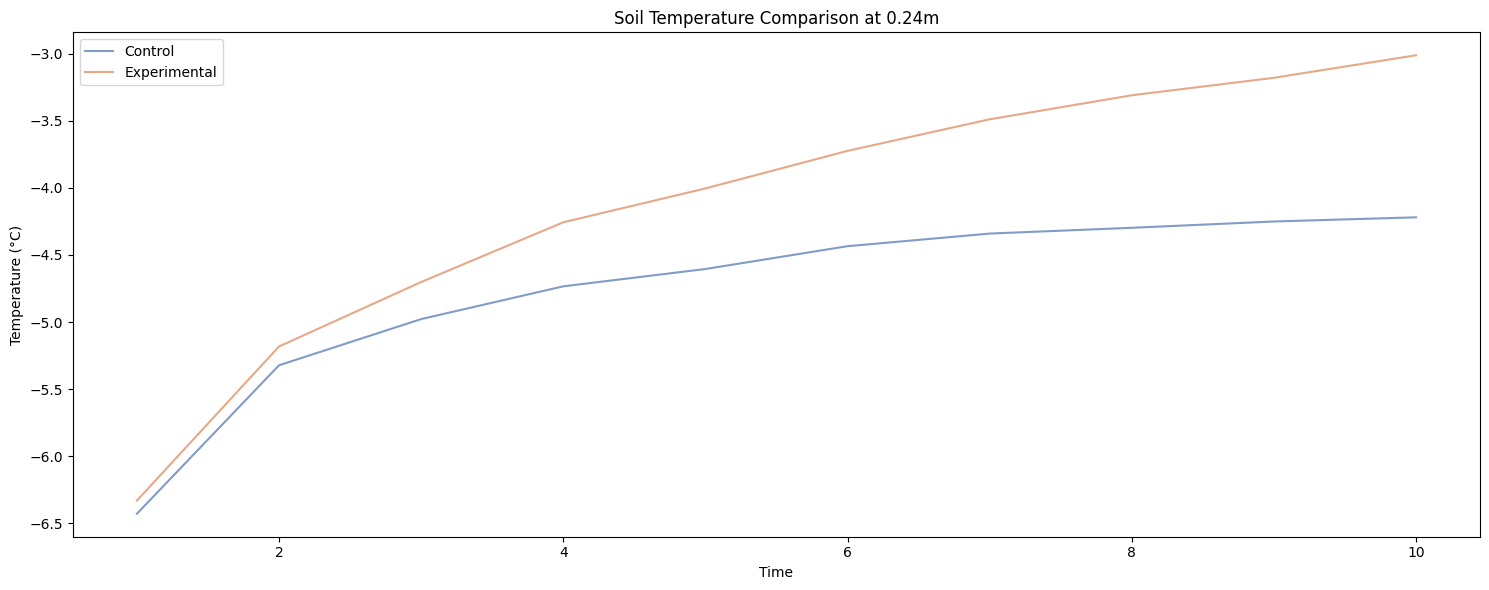

Statistics for 0.24m:
Control mean temperature: -4.76°C
Experimental mean temperature: -4.12°C
Temperature difference: 0.64°C
T-statistic: -1.6318
P-value: 0.1201




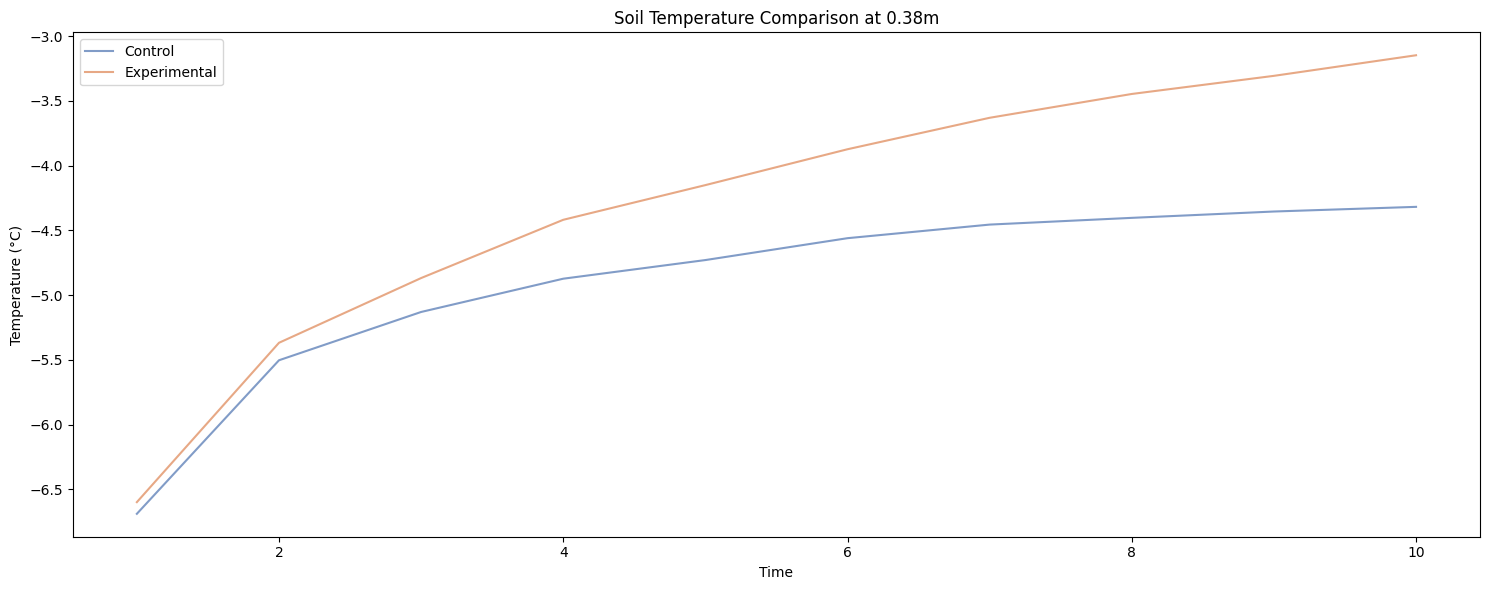

Statistics for 0.38m:
Control mean temperature: -4.90°C
Experimental mean temperature: -4.28°C
Temperature difference: 0.62°C
T-statistic: -1.5057
P-value: 0.1495




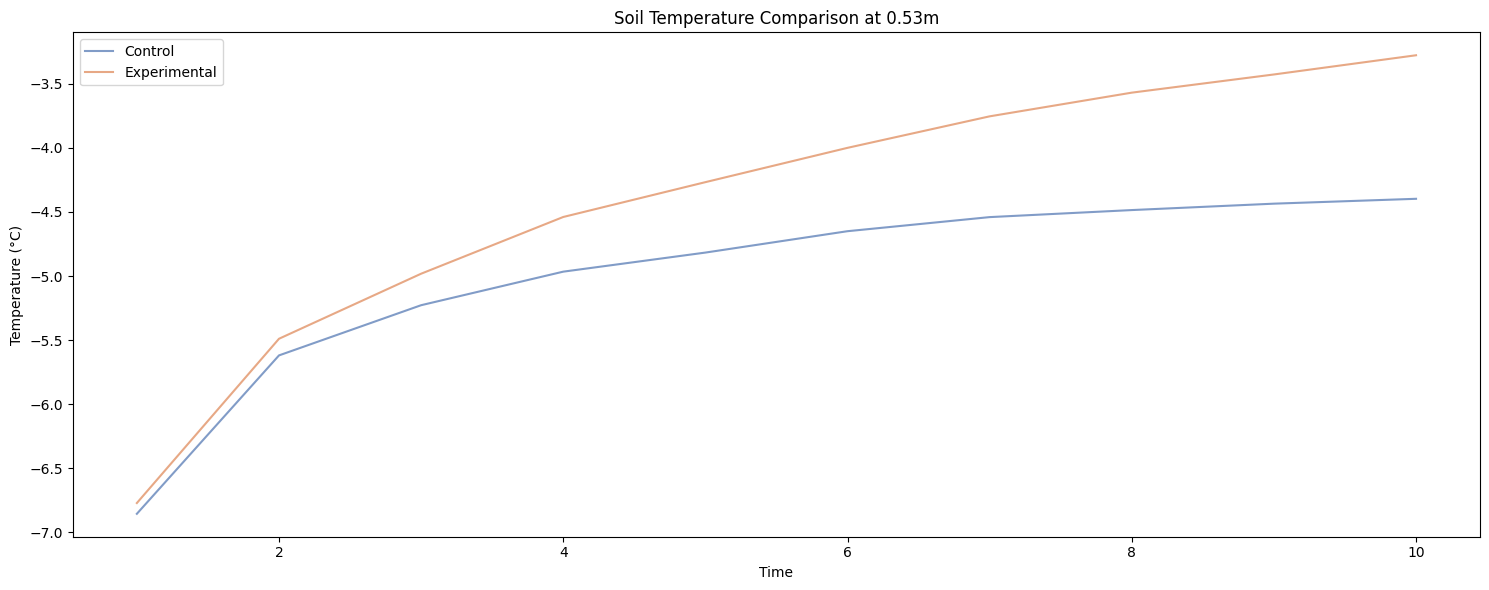

Statistics for 0.53m:
Control mean temperature: -5.00°C
Experimental mean temperature: -4.41°C
Temperature difference: 0.59°C
T-statistic: -1.4098
P-value: 0.1756




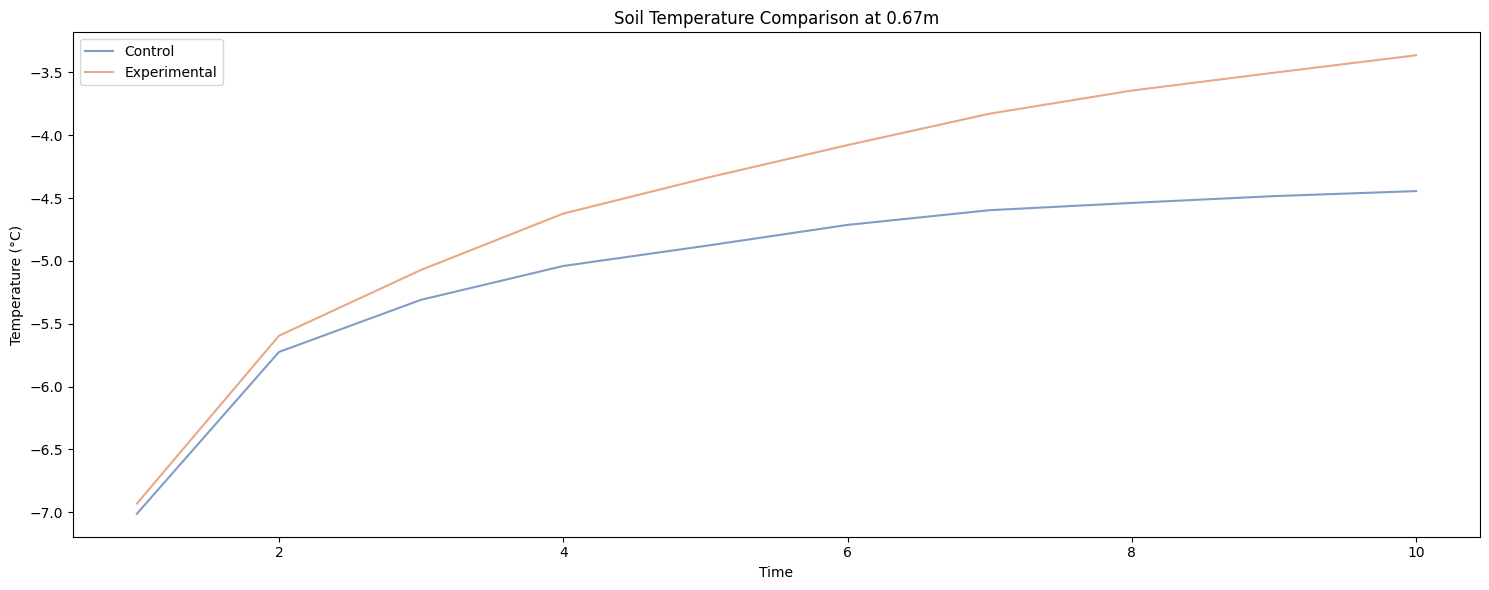

Statistics for 0.67m:
Control mean temperature: -5.07°C
Experimental mean temperature: -4.50°C
Temperature difference: 0.58°C
T-statistic: -1.3345
P-value: 0.1987




In [24]:
def plot_comparison(depth):
    plt.figure(figsize=(15, 6))
    plt.plot(control_df.index, control_df[depth], label='Control', alpha=0.7)
    plt.plot(experimental_df.index, experimental_df[depth], label='Experimental', alpha=0.7)
    plt.title(f'Soil Temperature Comparison at {depth}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig(f'comparison_{depth}.png')
    # plt.close()

    # Calculate and print statistics
    control_mean = control_df[depth].mean()
    exp_mean = experimental_df[depth].mean()
    temp_diff = exp_mean - control_mean
    t_stat, p_value = stats.ttest_ind(control_df[depth], experimental_df[depth])
    
    print(f"Statistics for {depth}:")
    print(f"Control mean temperature: {control_mean:.2f}°C")
    print(f"Experimental mean temperature: {exp_mean:.2f}°C")
    print(f"Temperature difference: {temp_diff:.2f}°C")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print("\n")

# Plot comparisons for each depth
for depth in depths:
    plot_comparison(depth)

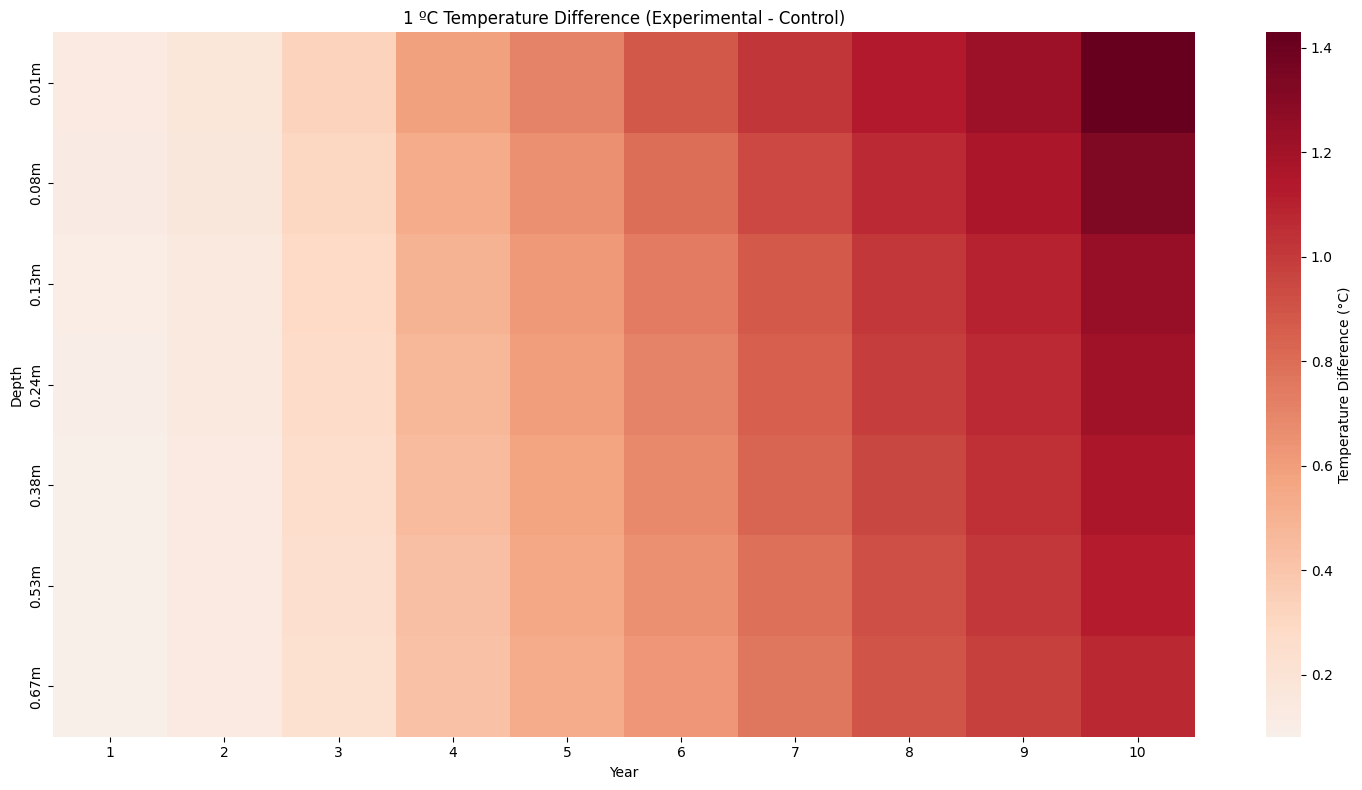

In [5]:
# Function to plot temperature difference heatmap
def plot_heatmap():
    # Calculate temperature differences
    diff_data = experimental_df[depths].values - control_df[depths].values

    # Create a heatmap of temperature differences
    plt.figure(figsize=(15, 8))
    sns.heatmap(diff_data.T, cmap='RdBu_r', center=0, cbar_kws={'label': 'Temperature Difference (°C)'}, 
                yticklabels=depths, xticklabels=control_df.index)
    plt.title('1 ºC Temperature Difference over 10 years (Experimental - Control)')
    plt.xlabel('Year')
    plt.ylabel('Depth')
    plt.tight_layout()
    plt.show()
    # Optionally save the heatmap
    # plt.savefig('temperature_difference_heatmap.png')
    # plt.close()

# Call the heatmap plotting function
plot_heatmap()

In [ ]:
# Script for analyzing # of thawing degree days and # of freezing degree days